In [63]:
# code from https://stackoverflow.com/questions/74386394/changing-color-of-a-specific-object-in-an-image-using-opencv

import cv2
import numpy as np


img = cv2.imread("ball.png")
if img is None:
    raise FileNotFoundError("Could not read image. Check path and filename!")
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# for sofa
#lower = np.array([90, 100, 20])
#upper = np.array([120, 255, 255])

# Blue sky range (OpenCV HSV scale)
# Hue is [0,179], Saturation and Value are [0,255]
lower = np.array([80, 90, 20])
upper = np.array([179, 255, 250])


mask = cv2.inRange(hsv, lower, upper)
inv_mask = cv2.bitwise_not(mask)

h, s, v = cv2.split(hsv)
h = np.mod(h + 170, 180)
s = np.clip(s - 100, 0, 255)
v = np.clip(v + 40, 0, 255)
hsv = cv2.merge([h, s, v])

bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

result = cv2.bitwise_or(cv2.bitwise_and(img, img, mask=inv_mask), cv2.bitwise_and(bgr, bgr, mask=mask))

cv2.imwrite("out.jpg", result)

True

error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.simd_helpers.hpp:92: error: (-15:Bad number of channels) in function '__cdecl cv::impl::`anonymous-namespace'::CvtHelper<struct cv::impl::`anonymous namespace'::Set<3,4,-1>,struct cv::impl::A0xb60a28d2::Set<3,-1,-1>,struct cv::impl::A0xb60a28d2::Set<0,5,-1>,4>::CvtHelper(const class cv::_InputArray &,const class cv::_OutputArray &,int)'
> Invalid number of channels in input image:
>     'VScn::contains(scn)'
> where
>     'scn' is 1


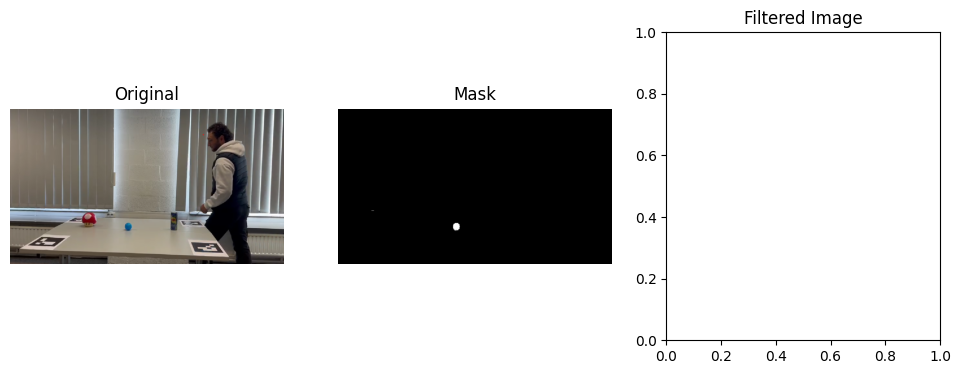

In [ ]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt

def detect_color(image_path,color, tuning=25):
    """_summary_ detect color in image and return mask
                 image should be in BGR format

    Args:
        image_path (array): _path to image
        color (np.array): representing the color in RGB  
    """
    
    hsv = cv2.cvtColor(image_path, cv2.COLOR_BGR2HSV)
    
    hsv_color = cv2.cvtColor(color,cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv_color)
    
    # define range of blue color in HSV
    H = h[0][0]
    lower = np.array([H-25 ,100,100])
    upper = np.array([H+25,255,255])
    mask = cv2.inRange(hsv, lower, upper)
    
    return mask
    
def change_color(image, orig_rgb, target_rgb, tuning=25):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    mask = detect_color(image, orig_rgb, tuning)
    
    orig_hsv = cv2.cvtColor(orig_rgb, cv2.COLOR_RGB2HSV)[0][0]
    target_hsv = cv2.cvtColor(target_rgb, cv2.COLOR_RGB2HSV)[0][0]

    delta_h = (int(target_hsv[0]) - int(orig_hsv[0])) % 180
    if delta_h > 90:
        delta_h -= 180

    delta_s = int(target_hsv[1]) - int(orig_hsv[1])
    delta_v = int(target_hsv[2]) - int(orig_hsv[2])
    
    h, s, v = cv2.split(hsv)
    h = np.mod(h + delta_h, 180).astype(np.uint8)
    s = np.clip(s + delta_s, 0, 255).astype(np.uint8)
    v = np.clip(v + delta_v, 0, 255).astype(np.uint8)
    
    hsv_shifted = cv2.merge([h, s, v])
    bgr_shifted = cv2.cvtColor(hsv_shifted, cv2.COLOR_HSV2BGR)
    
    result = cv2.bitwise_or(
        cv2.bitwise_and(image, image, mask=cv2.bitwise_not(mask)),
        cv2.bitwise_and(bgr_shifted, bgr_shifted, mask=mask)
    )
    
    return result


img = cv2.imread('oneFrame.png')


# --- Show with matplotlib (for inline visualization) ---
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title('Original')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
orig_rgb = np.uint8([[[255,0,0]]])
plt.subplot(1,3,2)
plt.title('Mask')
plt.imshow(detect_color(img ,orig_rgb ),cmap='gray')
plt.axis('off')
target_rgb = np.uint8([[[0,255,0]]])
plt.subplot(1,3,3)
plt.title('Filtered Image')
plt.imshow(cv2.cvtColor(change_color(img,orig_rgb,target_rgb), cv2.COLOR_BGR2RGB))  # convert BGR→RGB for plt
plt.axis('off')

plt.tight_layout()
plt.show()